# Hotazel Steam: Revenue Forecasting Analysis
**Author:** Eshaal Iqbal

## Business Question
Hotazel Steam wants a reliable way to forecast monthly revenue using operating data
(production volume) and weather-driven demand (heating/cooling degree days). This
notebook builds and compares several regression models of increasing complexity to
find the one that predicts revenue most accurately on unseen data.

## Approach
1. Explore the data and visualize how revenue relates to production and weather.
2. Fit a simple linear regression (production only) as a baseline.
3. Add heating degree days (`heatDD`) as a second predictor (multiple regression).
4. Test whether revenue behaves differently in winter/summer using dummy variables
   and a winter-production interaction term.
5. Evaluate every model on a held-out test set using mean absolute percentage error
   (MAPE), and visualize actual vs. predicted revenue.

## Data
Source file: `AICPA_regressionAnalysisData.csv`, with a `type` column that pre-splits
rows into `dt4training` and `dt4testing`.


## 1. Setup

In [ ]:
# Importing core data handling, plotting, and statistical modeling libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Show floats with 2 decimal places instead of scientific notation
pd.options.display.float_format = '{:.2f}'.format


## 2. Load and Inspect the Data

In [ ]:
# Load the raw dataset and parse the date column as an actual datetime
# (not just a string) so it can be used for time-based plotting later
revenue_df = pd.read_csv('AICPA_regressionAnalysisData.csv')
revenue_df['date'] = pd.to_datetime(revenue_df['date'])
revenue_df.head()


,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114


In [ ]:
# Quick sanity check on column types and missing values
revenue_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   type        48 non-null     object        
 1   date        48 non-null     datetime64[ns]
 2   revenue     48 non-null     int64         
 3   production  48 non-null     int64         
 4   coolDD      48 non-null     int64         
 5   heatDD      48 non-null     int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 2.4+ KB


## 3. Visualizing Monthly Revenue

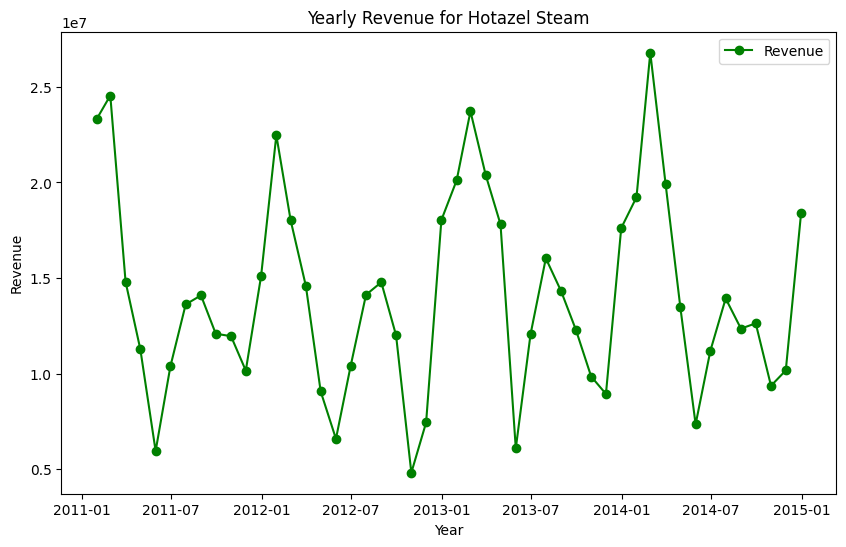

In [ ]:
# Plot revenue over time to get a first look at the overall trend/seasonality
plt.figure(figsize=(10, 6))
plt.title('Yearly Revenue for Hotazel Steam')
plt.xlabel('Year')
plt.ylabel('Revenue')

plt.plot(revenue_df['date'], revenue_df['revenue'], color='green', marker='o', label='Revenue')
plt.legend()
plt.show()


### Heating vs. Cooling Demand

In [ ]:
# Flag each month as heating- or cooling-dominant, to see whether the
# dominant weather driver relates to the revenue level
revenue_df['dominant_use'] = np.where(
    revenue_df['heatDD'] > revenue_df['coolDD'], 'heating', 'cooling'
)
revenue_df.sample(5)


,type,date,revenue,production,coolDD,heatDD,dominant_use
14,dt4training,2012-03-31,14575856,410248,0,438,heating
37,dt4testing,2014-02-28,26792280,714128,0,938,heating
8,dt4training,2011-09-30,12085472,567424,195,19,cooling
29,dt4training,2013-06-30,12064192,394400,278,4,cooling
24,dt4training,2013-01-31,20113488,531336,0,899,heating


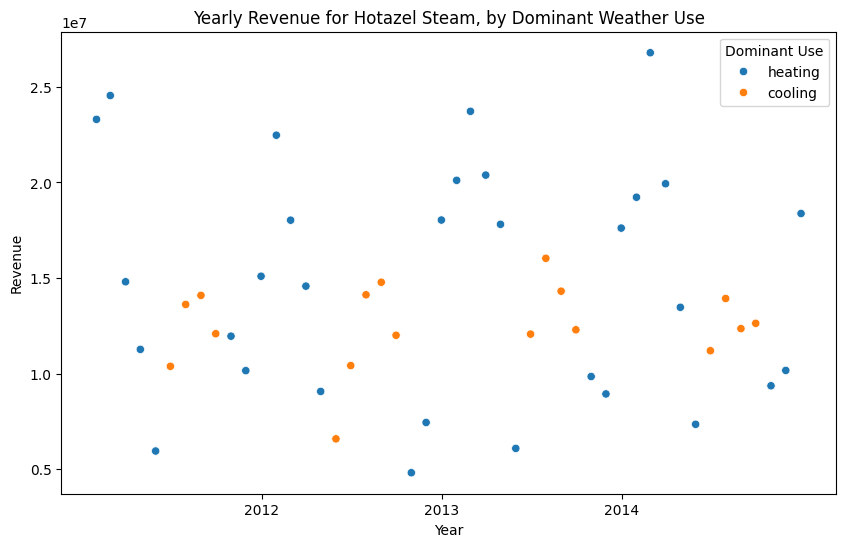

In [ ]:
# Same revenue-over-time plot, now colored by dominant weather use
plt.figure(figsize=(10, 6))
plt.title('Yearly Revenue for Hotazel Steam, by Dominant Weather Use')

sns.scatterplot(data=revenue_df, x='date', y='revenue', hue='dominant_use', marker='o')

plt.xlabel('Year')
plt.ylabel('Revenue')

# Force x-axis ticks to show one label per year instead of every data point
date_range = pd.date_range(start=revenue_df['date'].min(), end=revenue_df['date'].max(), freq='YS')
plt.xticks(date_range, date_range.year)
plt.legend(title='Dominant Use')
plt.show()


### Revenue vs. Production

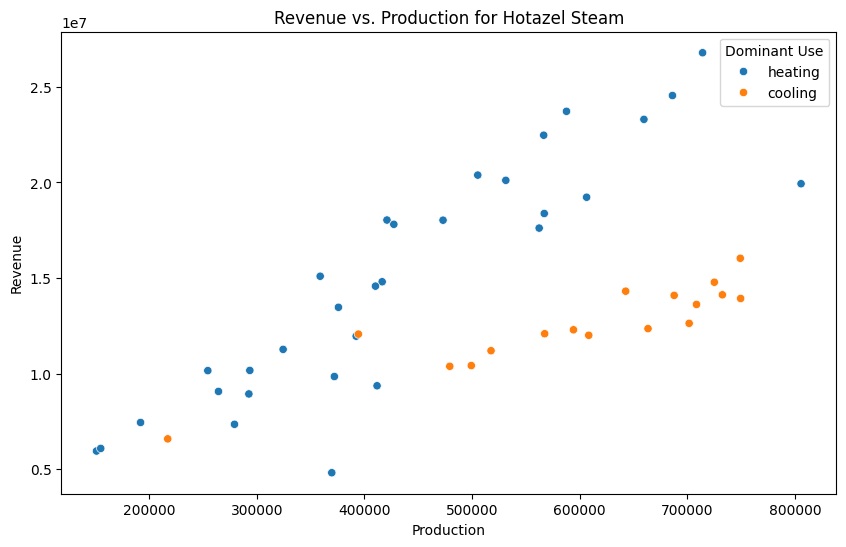

In [ ]:
# Check whether revenue scales with production, and whether that relationship differs between heating and cooling-dominant months
plt.figure(figsize=(10, 6))
plt.title('Revenue vs. Production for Hotazel Steam')

sns.scatterplot(data=revenue_df, x='production', y='revenue', hue='dominant_use', marker='o')

plt.xlabel('Production')
plt.ylabel('Revenue')
plt.legend(title='Dominant Use')
plt.show()


## 4. Correlation Analysis

In [ ]:
# Check how strongly each candidate predictor correlates with revenue
revenue_df[['revenue', 'production', 'coolDD', 'heatDD']].corr()


,revenue,production,coolDD,heatDD
revenue,1.00,0.63,-0.17,0.69
production,0.63,1.00,0.51,0.03
coolDD,-0.17,0.51,1.00,-0.72
heatDD,0.69,0.03,-0.72,1.00


`heatDD` and `production` both correlate more strongly with revenue than `coolDD`
does, which is why heating degree days (rather than cooling degree days) is the
weather variable carried forward into the multiple regression model below.

## 5. Training vs. Testing Data

In [ ]:
# Confirm how many rows are labeled training vs. testing
pd.crosstab(revenue_df['type'], columns='count')


col_0,count
type,
dt4testing,12
dt4training,36


In [ ]:
# The dataset already pre-labels each row as training or testing (column: 'type').
# .copy() is used here so later edits to these subsets never silently mutate revenue_df.
train_df = revenue_df.loc[revenue_df['type'] == 'dt4training'].copy()
test_df = revenue_df.loc[revenue_df['type'] == 'dt4testing'].copy()

train_df.head()


,type,date,revenue,production,coolDD,heatDD,dominant_use
0,dt4training,2011-01-31,23304096,659640,0,1021,heating
1,dt4training,2011-02-28,24552000,686144,0,794,heating
2,dt4training,2011-03-31,14804728,416464,0,714,heating
3,dt4training,2011-04-30,11265320,324456,1,354,heating
4,dt4training,2011-05-31,5945904,151104,72,114,heating


In [ ]:
test_df.head()


,type,date,revenue,production,coolDD,heatDD,dominant_use
36,dt4testing,2014-01-31,19228840,606400,0,1123,heating
37,dt4testing,2014-02-28,26792280,714128,0,938,heating
38,dt4testing,2014-03-31,19935840,805600,0,866,heating
39,dt4testing,2014-04-30,13468000,375856,0,412,heating
40,dt4testing,2014-05-31,7344128,279296,49,88,heating


## 6. Model 1: Simple Linear Regression (Production Only)

A baseline model using production alone as the predictor of revenue.

In [ ]:
# Fit OLS with production as the only predictor
X = sm.add_constant(train_df['production'])
y = train_df['revenue']

model_simple = sm.OLS(y, X).fit()
model_simple.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     22.35
Date:                Sat, 01 Aug 2026   Prob (F-statistic):           3.86e-05
Time:                        01:56:38   Log-Likelihood:                -598.32
No. Observations:                  36   AIC:                             1201.
Df Residuals:                      34   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.898e+06   2.01e+06      2.431      0.020    8.03e+05    8.99e+06
production    18.9920      4.017      4.728      0.000      10.828      27.156
==============================================================================
Omnibus:                        5.412   Durbin-Watson:                   0.444
Prob(Omnibus):                  0.067   Jarque-Bera (JB):                2.625
Skew:                           0.392   Prob(JB):                        0.269
Kurtosis:                       1.934   Cond. No.                     1.47e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Pulling out just the coefficients for easy reference
model_simple.params


,0
const,4897663.26
production,18.99


**Regression equation:** Revenue = 4,897,663.26 + 18.99 × Production

**Interpretation:** for every one-unit (1,000 lb) increase in production, revenue
is predicted to increase by about $18.99, holding all else constant.

### Evaluating Model 1 on the Test Set

In [ ]:
# Predict revenue on the held-out test set using Model 1
X_test = sm.add_constant(test_df[['production']])
test_df['simple_predicted'] = model_simple.predict(X_test)
test_df.head()


,type,date,revenue,production,coolDD,heatDD,dominant_use,simple_predicted
36,dt4testing,2014-01-31,19228840,606400,0,1123,heating,16414428.69
37,dt4testing,2014-02-28,26792280,714128,0,938,heating,18460401.82
38,dt4testing,2014-03-31,19935840,805600,0,866,heating,20197640.55
39,dt4testing,2014-04-30,13468000,375856,0,412,heating,12035930.72
40,dt4testing,2014-05-31,7344128,279296,49,88,heating,10202060.55


In [ ]:
# Percentage error per row = how far off the prediction is, as a % of actual revenue
test_df['simple_pct_error'] = abs(
    100 * (test_df['revenue'] - test_df['simple_predicted']) / test_df['revenue']
)

# Mean absolute percentage error (MAPE) across the whole test set
mape_simple = test_df['simple_pct_error'].mean()
print(f'Model 1 (Simple Linear Regression) MAPE: {mape_simple:.2f}%')


Model 1 (Simple Linear Regression) MAPE: 25.42%


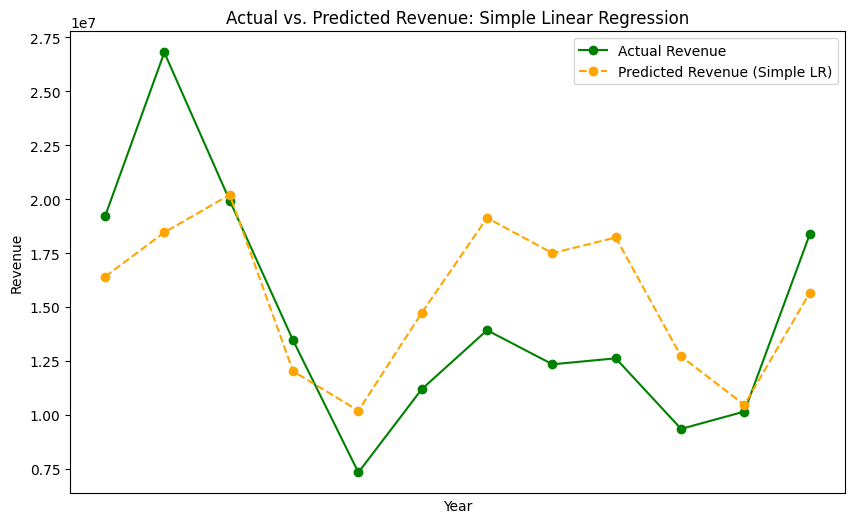

In [ ]:
import statsmodels.api as sm

# Plot actual vs. predicted revenue over time to visualize the fit
plt.figure(figsize=(10, 6))
plt.title('Actual vs. Predicted Revenue: Simple Linear Regression')
plt.xlabel('Year')
plt.ylabel('Revenue')

# Re-calculating simple_predicted as test_df was redefined later in the notebook
X_test_simple = sm.add_constant(test_df[['production']])
test_df['simple_predicted'] = model_simple.predict(X_test_simple)

plt.plot(test_df['date'], test_df['revenue'], color='green', marker='o', label='Actual Revenue')
plt.plot(test_df['date'], test_df['simple_predicted'], color='orange', marker='o',
         linestyle='dashed', label='Predicted Revenue (Simple LR)')

date_range = pd.date_range(start=test_df['date'].min(), end=test_df['date'].max(), freq='YS')
plt.xticks(date_range, date_range.year)
plt.legend()
plt.show()

## 7. Model 2: Multiple Regression (Production + heatDD)

Adding heating degree days to see whether weather-driven demand improves the fit.

In [ ]:
# Fit OLS with production and heatDD as predictors
X = sm.add_constant(train_df[['production', 'heatDD']])
y = train_df['revenue']

model_multi = sm.OLS(y, X).fit()
model_multi.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     107.4
Date:                Sat, 01 Aug 2026   Prob (F-statistic):           3.58e-15
Time:                        01:56:39   Log-Likelihood:                -571.12
No. Observations:                  36   AIC:                             1148.
Df Residuals:                      33   BIC:                             1153.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.273e+05   1.04e+06      0.702      0.487   -1.38e+06    2.83e+06
production    19.9992      1.918     10.427      0.000      16.097      23.901
heatDD      1.048e+04    971.360     10.793      0.000    8507.807    1.25e+04
==============================================================================
Omnibus:                        3.398   Durbin-Watson:                   1.229
Prob(Omnibus):                  0.183   Jarque-Bera (JB):                2.206
Skew:                          -0.344   Prob(JB):                        0.332
Kurtosis:                       3.998   Cond. No.                     1.59e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.59e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model_multi.params


,0
const,727257.88
production,20.00
heatDD,10484.05


**Regression equation:** Revenue = 727,257.88 + 20.00 × Production + 10,484.05 × heatDD

### Evaluating Model 2 on the Test Set

In [ ]:
# Predict revenue on the test set using Model 2
X_test = sm.add_constant(test_df[['production', 'heatDD']])
test_df['multi_predicted'] = model_multi.predict(X_test)

# Percentage error and MAPE, same approach as Model 1
test_df['multi_pct_error'] = abs(
    100 * (test_df['revenue'] - test_df['multi_predicted']) / test_df['revenue']
)
mape_multi = test_df['multi_pct_error'].mean()
print(f'Model 2 (Multiple Regression) MAPE: {mape_multi:.2f}%')


Model 2 (Multiple Regression) MAPE: 13.86%


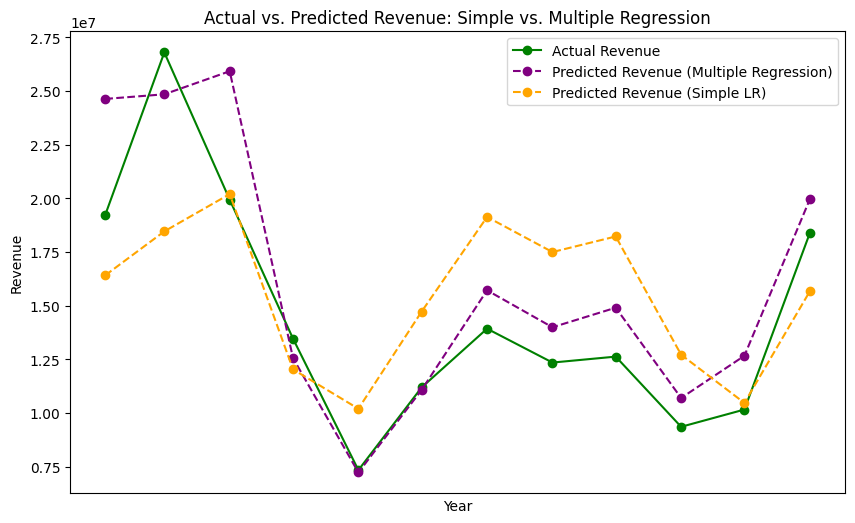

In [ ]:
# Plot actual revenue against both models' predictions to compare fit
plt.figure(figsize=(10, 6))
plt.title('Actual vs. Predicted Revenue: Simple vs. Multiple Regression')
plt.xlabel('Year')
plt.ylabel('Revenue')

# Re-calculating simple_predicted and multi_predicted as test_df was redefined later in the notebook
import statsmodels.api as sm

X_test_simple = sm.add_constant(test_df[['production']])
test_df['simple_predicted'] = model_simple.predict(X_test_simple)

X_test_multi = sm.add_constant(test_df[['production', 'heatDD']])
test_df['multi_predicted'] = model_multi.predict(X_test_multi)

plt.plot(test_df['date'], test_df['revenue'], color='green', marker='o', label='Actual Revenue')
plt.plot(test_df['date'], test_df['multi_predicted'], color='purple', marker='o',
         linestyle='dashed', label='Predicted Revenue (Multiple Regression)')
plt.plot(test_df['date'], test_df['simple_predicted'], color='orange', marker='o',
         linestyle='dashed', label='Predicted Revenue (Simple LR)')

date_range = pd.date_range(start=test_df['date'].min(), end=test_df['date'].max(), freq='YS')
plt.xticks(date_range, date_range.year)
plt.legend()
plt.show()

### Checking Model 2's Residuals

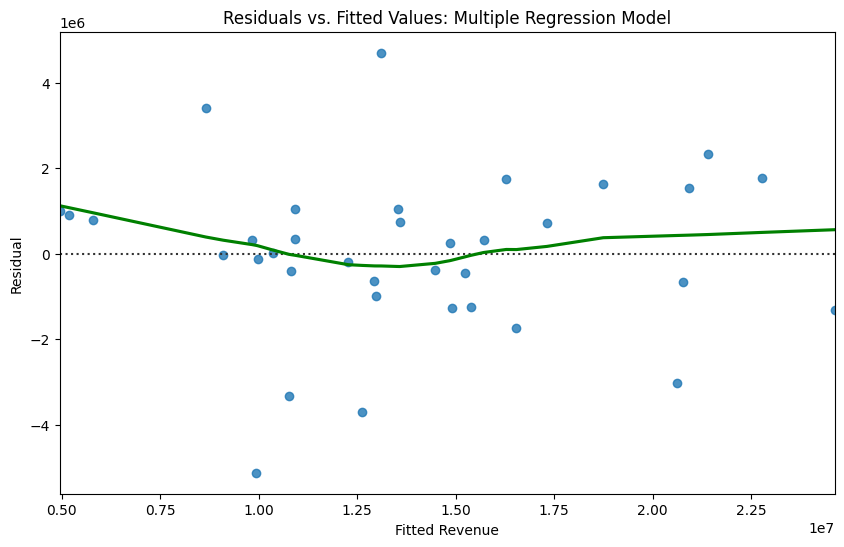

In [ ]:
# A quick residual check: if the model's assumptions hold reasonably well,
# residuals should scatter randomly around zero with no obvious pattern
plt.figure(figsize=(10, 6))
sns.residplot(x=model_multi.fittedvalues, y=model_multi.resid, lowess=True,
              line_kws={'color': 'green'})
plt.title('Residuals vs. Fitted Values: Multiple Regression Model')
plt.xlabel('Fitted Revenue')
plt.ylabel('Residual')
plt.show()


Compared to Model 1, Model 2's mean percentage error is notably lower, and the
predicted-revenue line tracks the actual data more closely, especially in
higher-revenue periods. This suggests weather (via `heatDD`) explains meaningful
revenue variation that production alone misses.

## 8. Model 3: Seasonal Dummy Variables (Winter / Summer)

Rather than a continuous weather variable, this model tests whether revenue
behaves differently by season using binary (dummy) indicators.

In [ ]:
# Winter = Dec, Jan, Feb. Summer = Jun, Jul, Aug.
revenue_df['winter'] = np.where(revenue_df['date'].dt.month.isin([12, 1, 2]), 1, 0)
revenue_df['summer'] = np.where(revenue_df['date'].dt.month.isin([6, 7, 8]), 1, 0)

# Re-split now that the season flags exist on revenue_df
train_df = revenue_df.loc[revenue_df['type'] == 'dt4training'].copy()
test_df = revenue_df.loc[revenue_df['type'] == 'dt4testing'].copy()

revenue_df.head()


,type,date,revenue,production,coolDD,heatDD,dominant_use,winter,summer
0,dt4training,2011-01-31,23304096,659640,0,1021,heating,1,0
1,dt4training,2011-02-28,24552000,686144,0,794,heating,1,0
2,dt4training,2011-03-31,14804728,416464,0,714,heating,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,heating,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,heating,0,0


In [ ]:
# Fit OLS with production and the winter flag as predictors
X = sm.add_constant(train_df[['production', 'winter']])
y = train_df['revenue']

model_winter = sm.OLS(y, X).fit()
model_winter.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     51.04
Date:                Sat, 01 Aug 2026   Prob (F-statistic):           7.95e-11
Time:                        01:56:41   Log-Likelihood:                -582.04
No. Observations:                  36   AIC:                             1170.
Df Residuals:                      33   BIC:                             1175.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.049e+06    1.3e+06      3.879      0.000     2.4e+06     7.7e+06
production    14.7968      2.664      5.555      0.000       9.378      20.216
winter       7.31e+06   1.05e+06      6.965      0.000    5.17e+06    9.44e+06
==============================================================================
Omnibus:                       11.012   Durbin-Watson:                   1.113
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               10.941
Skew:                           1.006   Prob(JB):                      0.00421
Kurtosis:                       4.802   Cond. No.                     1.48e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.48e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Predict on the test set and compute MAPE, same pattern as before
X_test = sm.add_constant(test_df[['production', 'winter']])
test_df['winter_predicted'] = model_winter.predict(X_test)

test_df['winter_pct_error'] = abs(
    100 * (test_df['revenue'] - test_df['winter_predicted']) / test_df['revenue']
)
mape_winter = test_df['winter_pct_error'].mean()
print(f'Model 3 (Winter Dummy Variable) MAPE: {mape_winter:.2f}%')


Model 3 (Winter Dummy Variable) MAPE: 16.49%


### Visualizing the Winter vs. Non-Winter Trend Lines

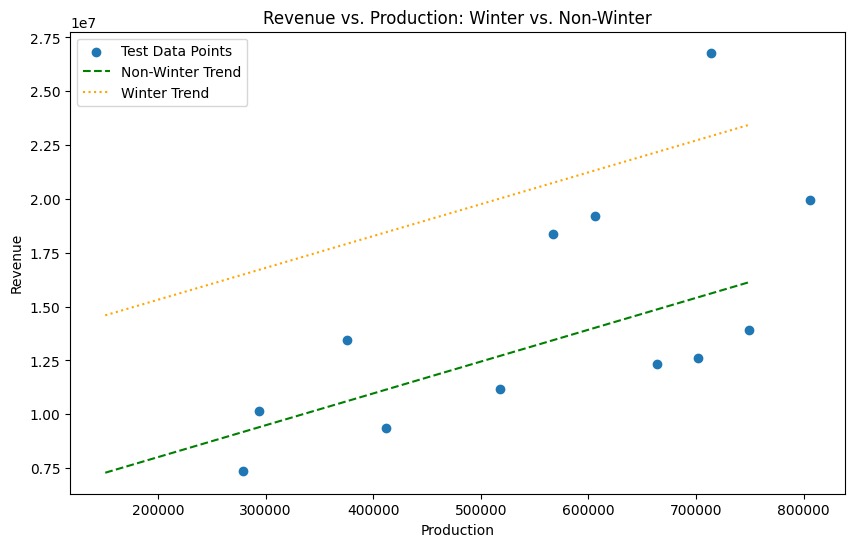

In [ ]:
# Extract coefficients so the winter and non-winter trend lines can be
# drawn separately over a range of production values
intercept, slope_production, slope_winter = model_winter.params

production_range = np.linspace(train_df['production'].min(), train_df['production'].max(), 100)
non_winter_line = intercept + slope_production * production_range
winter_line = (intercept + slope_winter) + slope_production * production_range

plt.figure(figsize=(10, 6))
plt.scatter(test_df['production'], test_df['revenue'], label='Test Data Points')
plt.xlabel('Production')
plt.ylabel('Revenue')

plt.plot(production_range, non_winter_line, color='green', linestyle='--', label='Non-Winter Trend')
plt.plot(production_range, winter_line, color='orange', linestyle=':', label='Winter Trend')

plt.title('Revenue vs. Production: Winter vs. Non-Winter')
plt.legend()
plt.show()


## 9. Model 4: Winter + Summer Dummy Variables

Extending Model 3 to test summer separately from the non-winter/non-summer baseline.

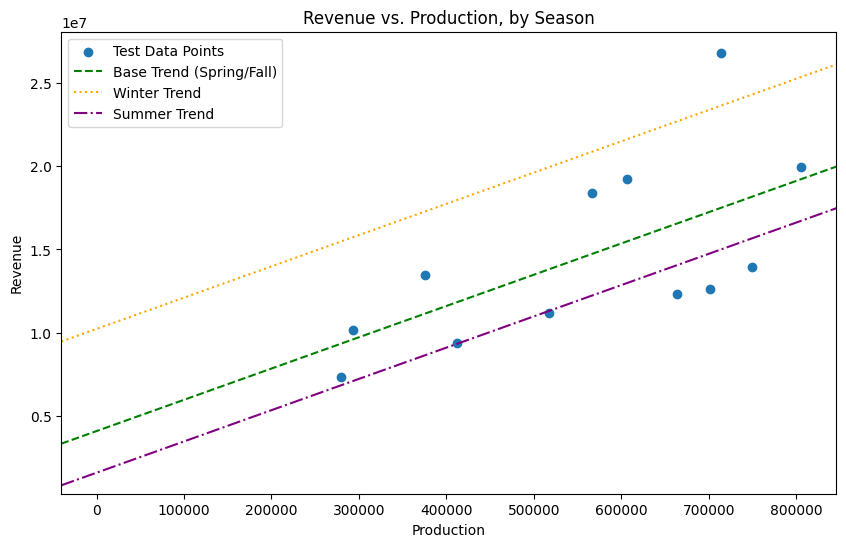

In [ ]:
# Fit OLS with production, winter, and summer as predictors
X = sm.add_constant(train_df[['production', 'winter', 'summer']])
y = train_df['revenue']

model_seasonal = sm.OLS(y, X).fit()
intercept, slope_production, slope_winter, slope_summer = model_seasonal.params

# Plot three parallel trend lines: base (spring/fall), winter, and summer
plt.figure(figsize=(10, 6))
plt.scatter(test_df['production'], test_df['revenue'], label='Test Data Points')
plt.xlabel('Production')
plt.ylabel('Revenue')

plt.axline(xy1=(0, intercept), slope=slope_production, color='green', linestyle='--',
           label='Base Trend (Spring/Fall)')
plt.axline(xy1=(0, intercept + slope_winter), slope=slope_production, color='orange',
           linestyle=':', label='Winter Trend')
plt.axline(xy1=(0, intercept + slope_summer), slope=slope_production, color='purple',
           linestyle='-.', label='Summer Trend')

plt.title('Revenue vs. Production, by Season')
plt.legend()
plt.show()


## 10. Model 5: Winter x Production Interaction Term

Tests whether the *slope* of the production-revenue relationship itself changes
in winter, not just the intercept.

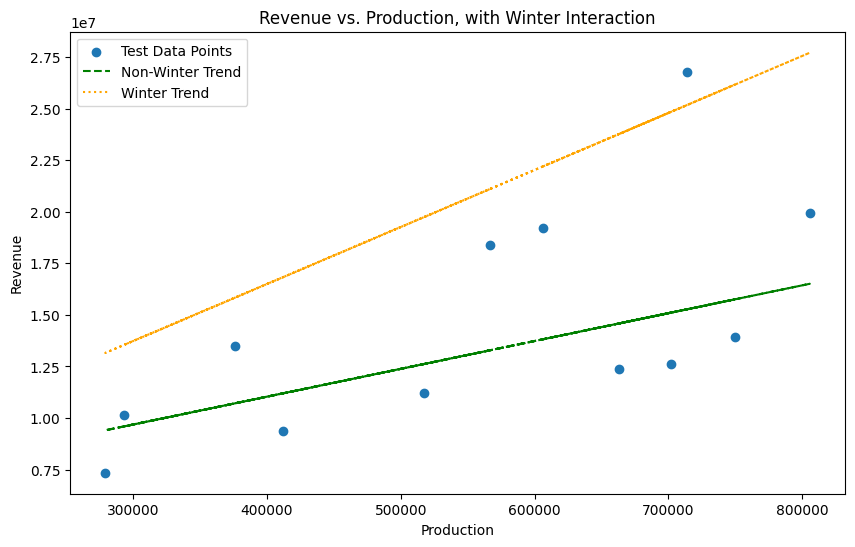

In [ ]:
# Interaction term = production * winter, lets the production slope
# itself differ between winter and non-winter months
train_df['winter_interaction'] = train_df['production'] * train_df['winter']

X = sm.add_constant(train_df[['production', 'winter', 'winter_interaction']])
y = train_df['revenue']

model_interaction = sm.OLS(y, X).fit()
intercept, slope_production, slope_winter, slope_interaction = model_interaction.params

# Build separate winter/non-winter lines using the interaction coefficient
non_winter_line = intercept + slope_production * test_df['production']
winter_line = (intercept + slope_winter) + (slope_production + slope_interaction) * test_df['production']

plt.figure(figsize=(10, 6))
plt.scatter(test_df['production'], test_df['revenue'], label='Test Data Points')
plt.xlabel('Production')
plt.ylabel('Revenue')

plt.plot(test_df['production'], non_winter_line, color='green', linestyle='--', label='Non-Winter Trend')
plt.plot(test_df['production'], winter_line, color='orange', linestyle=':', label='Winter Trend')

plt.title('Revenue vs. Production, with Winter Interaction')
plt.legend()
plt.show()


## 11. Summary of Results

In [28]:
summary_df = pd.DataFrame({
    'Model': ['1: Simple Linear Regression', '2: Multiple Regression', '3: Winter Dummy Variable'],
    'Predictors': ['production', 'production, heatDD', 'production, winter'],
    'MAPE (%)': [mape_simple, mape_multi, mape_winter]
})

summary_df

,Model,Predictors,MAPE (%)
0,1: Simple Linear Regression,production,25.42
1,2: Multiple Regression,"production, heatDD",13.86
2,3: Winter Dummy Variable,"production, winter",16.49


**Takeaway:** Adding `heatDD` in Model 2 reduced mean percentage error compared to
the production-only baseline, and the seasonal dummy variables (Models 3-5) show
that revenue's relationship with production shifts meaningfully in winter months.
This suggests any production forecast used for revenue planning should account for
seasonality rather than treating production as the sole driver of revenue.